In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [3]:
pd.set_option("display.max_rows",500)
df=pd.read_csv('Bengaluru_House_Data.csv')
df.head(5)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:

df.shape

(13320, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [7]:
df.drop(columns=['society'],axis=1,inplace=True)

In [8]:
df['balcony'].fillna(df['balcony'].median(),inplace=True)
df['bath'].fillna(df['bath'].median(),inplace=True)
df['location'].fillna('unknown',inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_6568\390473127.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(df['balcony'].median(),inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_6568\390473127.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [9]:
df=df.dropna(subset=['size'])

In [10]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

<Axes: >

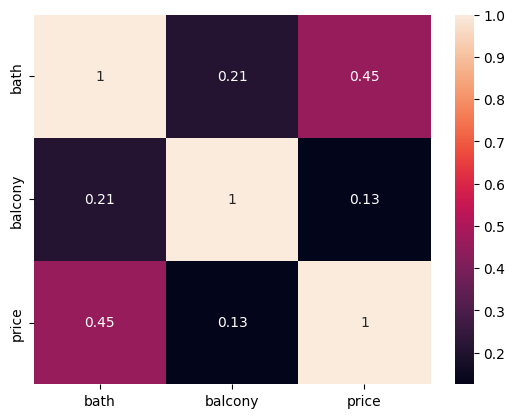

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

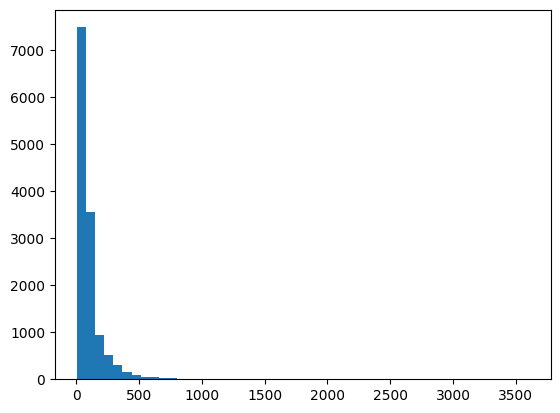

In [12]:
plt.hist(df['price'],bins=50)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_6568\107642734.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['price'],shade=True)


<Axes: xlabel='price', ylabel='Density'>

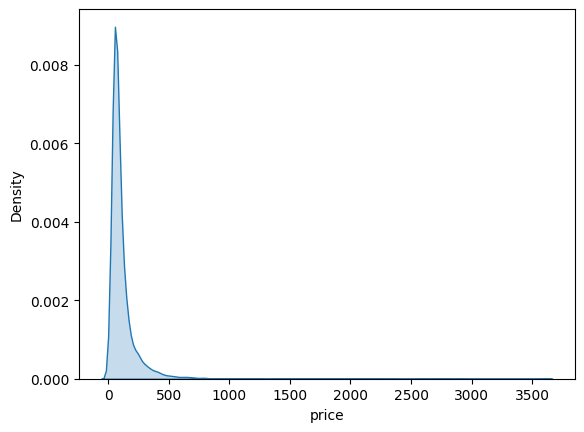

In [13]:
sns.kdeplot(df['price'],shade=True)

<Axes: xlabel='price', ylabel='total_sqft'>

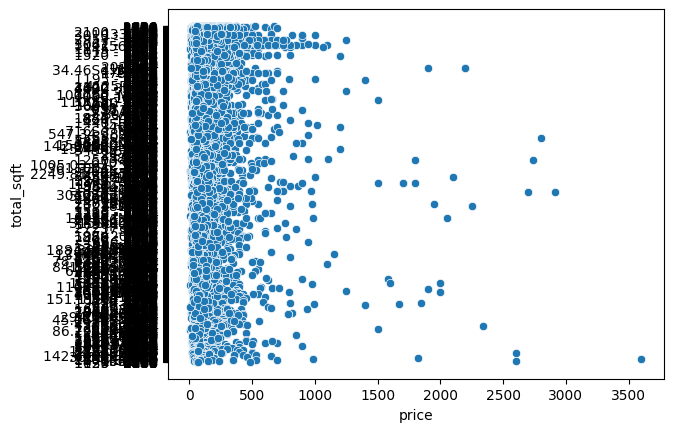

In [14]:
sns.scatterplot(x='price', y='total_sqft', data=df)

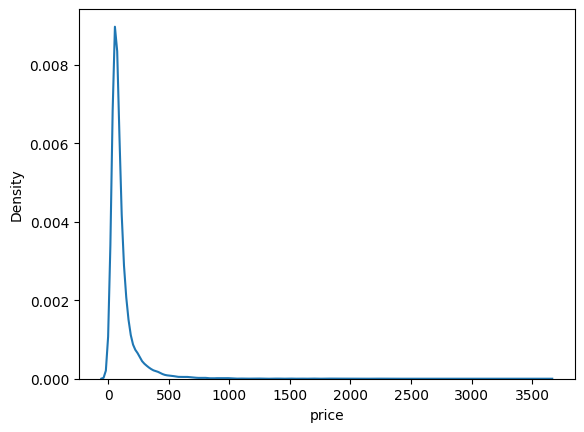

In [15]:
sns.kdeplot(df['price'])
plt.show()

In [31]:
X=df.iloc[:,:-1]
Y=df['price']

In [32]:
def convert_sqft(X):
    try:
        if '-' in str(X):
            a, b = X.split('-')
            return (float(a) + float(b)) / 2
        return float(X)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [33]:
df = df.dropna(subset=['total_sqft'])

In [34]:
numeric_features=['total_sqft','bath','balcony']
Categorical_features=['location','size','area_type','availability']

In [35]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [36]:
# Y=np.array(Y).reshape(-1,1)
# pt=PowerTransformer(method='yeo-johnson')
# Y_transformed=pt.fit_transform(Y.reshape(-1,1))
# Y_train=np.array(Y_train).reshape(-1,1)
# Y_test=np.array(Y_test).reshape(-1,1)
# Y_train_transformed=pt.fit_transform(Y_train)  
# Y_test_transformed=pt.transform(Y_test)


In [37]:
Processor=ColumnTransformer(transformers=[
    ('num',StandardScaler(),numeric_features),
    ('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),Categorical_features)
])

(max_depth=None,min_samples_split=5,min_samples_leaf=1,n_estimators=100,max_features='log2')

In [38]:
model=Pipeline(steps=[
    ("Processor",Processor),
    ("Regression-problem",RandomForestRegressor(max_depth=15,min_samples_split=15,min_samples_leaf=2,n_estimators=300,max_features=None))
])

In [39]:
import joblib
model.fit(X_train,Y_train)
joblib.dump(model,"model.pkl")

['model.pkl']

In [40]:
model.score(X_train,Y_train)*100,model.score(X_test,Y_test)*100

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


(75.38632888800583, 71.30921697752888)

In [41]:
Y_pred=model.predict(X_test)

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [42]:
mean_absolute_error(Y_test,Y_pred)*100

3187.1480004432287

In [43]:
mean_squared_error(Y_test,Y_pred)*100

613462.6264852695

In [44]:
r2_score(Y_test,Y_pred)*100

71.30921697752888

In [45]:
from sklearn.metrics import root_mean_squared_error

In [46]:
root_mean_squared_error(Y_test,Y_pred)*100

7832.385501782133

In [47]:
from scipy.stats import skew
# print(skew(Y_transformed))
# print(skew(Y_train))


In [ ]:
# plt.Figure(figsize=(5,6))
# plt.hist(Y,bins=50)
# plt.title("Before Transformer")
# plt.show()

# plt.hist(Y_train_transformed,bins=50)
# plt.title("After Transformer")
# plt.show()

In [ ]:
# scores=cross_val_score(model,X,Y,cv=5)
# print("scores",scores)
# print("scores- mean",scores.mean()*100)
# print("scores-std",scores.std()*100)

In [48]:
param_dist={
    'Regression-problem__n_estimators':[100,200,300,500],
    'Regression-problem__max_depth':[10,15,20,30,None],
    'Regression-problem__min_samples_split':[2,5,10,15],
    'Regression-problem__min_samples_leaf':[1,2,4,6],
    'Regression-problem__max_features':['sqrt','log2',None]
}
rd=RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',# recall     
    random_state=42,
    n_jobs=-1,
)
# rd.fit(X_train,Y_train)

In [161]:
print(rd.best_params_)
print(rd.best_score_)

{'Regression-problem__n_estimators': 300, 'Regression-problem__min_samples_split': 15, 'Regression-problem__min_samples_leaf': 2, 'Regression-problem__max_features': None, 'Regression-problem__max_depth': 15}
0.5719047055098706


## Prediction Site

In [49]:
new_buyer={
    "area_type":['plot Area'],
    "availability":['Ready To Move'],
    "location":['Kothanur'],
    "size":['2 BHK'],
    "total_sqft": [1200.0],
    "bath": [2.0],
    "balcony": [1.0]
}
dff=pd.DataFrame(new_buyer)
prediction=model.predict(dff)
print(prediction)

[60.26854227]


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
